In [1]:
# ==========================================
# Configuración del entorno (Colab o local)
# ==========================================

from pathlib import Path
import os
import sys
import subprocess

IS_COLAB = "google.colab" in sys.modules

# Instalar dependencias únicamente en Google Colab
if IS_COLAB:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "ultralytics==8.4.102",
        "matplotlib",
        "numpy",
        "pillow",
    ])

# Definir el directorio de trabajo
if IS_COLAB:
    SESSION_WORKSPACE = Path("/content/yolo_object_detection_session_03")
else:
    SESSION_WORKSPACE = Path.cwd() / "yolo_object_detection_session_03"

SESSION_WORKSPACE.mkdir(parents=True, exist_ok=True)
os.chdir(SESSION_WORKSPACE)

print(f"Entorno : {'Google Colab' if IS_COLAB else 'VS Code / Jupyter'}")
print(f"Directorio de trabajo: {SESSION_WORKSPACE}")


Entorno : VS Code / Jupyter
Directorio de trabajo: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Object Detection/Labs/yolo_object_detection_session_03


In [2]:
import torch

torch.manual_seed(0)

from ultralytics import YOLO, settings
from ultralytics.data.utils import check_det_dataset

print(f"CUDA disponible : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

CUDA disponible : True
GPU : NVIDIA GeForce RTX 3060


In [3]:
# Independent Colab assets — this notebook never reads another session's files.

SESSION_DATASETS = SESSION_WORKSPACE / "datasets"
settings.update({"datasets_dir": str(SESSION_DATASETS)})
COCO128_INFO = check_det_dataset("coco128.yaml", autodownload=True)
COCO128_YAML = Path(COCO128_INFO.get("yaml_file", "coco128.yaml"))
BASELINE_MODEL = YOLO("yolo11n.pt")  # Downloads and caches this notebook's pretrained weights.
print(f"dataset={COCO128_YAML} | model=yolo11n.pt")



WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Object Detection/Labs/yolo_object_detection_session_03/datasets/coco128/images/train2017'
Unzipping /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Object Detection/Labs/yolo_object_detection_session_03/datasets/coco128.zip to /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Object Detection/Labs/yolo_object_detection_session_03/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 804.7files/s 0.3s0.0s
Dataset download success ✅ (1.7s), saved to /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Object Detection/Labs/yolo_object_detection_session_03/datasets

dataset=/run/media/timoteo/HDD DATOS/conda/envs/pytorch_gpu/lib/python3.11/site-packages/ultralytics/cfg/datasets/coco128.yaml | model=yolo11n.pt


In [4]:
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd


SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
IN_COLAB = "google.colab" in sys.modules
RUN_REAL_MODEL = IN_COLAB  # Colab provisions COCO128 and yolo11n.pt automatically.
print(f"numpy={np.__version__} | pandas={pd.__version__} | torch={torch.__version__} | Colab={IN_COLAB}")

numpy=2.4.6 | pandas=3.0.3 | torch=2.12.1 | Colab=False


## 1. Read a training log

This controlled excerpt resembles fields a pinned Ultralytics release may report. Names and definitions are release-specific: interpret the **jobs**, and do not compare raw loss magnitudes across versions as if they shared one scale.

In [5]:
training_log = pd.DataFrame({
    "epoch": [1, 2, 3],
    "train/box_loss": [1.42, 1.18, 1.05],
    "train/cls_loss": [0.91, 0.72, 0.63],
    "train/dfl_loss": [1.31, 1.22, 1.17],
})
training_log

,epoch,train/box_loss,train/cls_loss,train/dfl_loss
0,1,1.42,0.91,1.31
1,2,1.18,0.72,1.22
2,3,1.05,0.63,1.17


`box_loss` and `dfl_loss` are localization-related in this pinned-family example; `cls_loss` is class-related. There is no separate column literally named `objectness`, because current releases may combine presence-related behavior into other objectives. These are differentiable training quantities—not the confidence, NMS IoU, or later evaluation IoU thresholds.

### Exercise E1 — weighted toy loss

Combine box loss `0.40`, class loss `0.20`, and conceptual presence loss `0.10` with weights `7.5`, `0.5`, and `1.0`.

In [6]:
# TODO: Calculate the three weighted contributions and their total.

losses = {"box": 0.40, "class": 0.20, "presence": 0.10}
weights = {"box": 7.5, "class": 0.5, "presence": 1.0}
weighted = {name: losses[name] * weights[name] for name in losses}
total_loss = sum(weighted.values())
print("weighted contributions:", weighted)
print(f"total loss={total_loss:.2f}")
assert np.isclose(total_loss, 3.20)

weighted contributions: {'box': 3.0, 'class': 0.1, 'presence': 0.1}
total loss=3.20


> TODO: Interpret what the weights do—and what the result does not prove.


## 2. Predict the threshold sweep before running it


The controlled candidates below represent one sparse and one crowded scene. They are deliberately redundant so both filtering stages have visible effects.

In [7]:
def box_iou_one_to_many(box, boxes):
    box = np.asarray(box, dtype=float)
    boxes = np.asarray(boxes, dtype=float)
    inter_wh = np.maximum(0.0, np.minimum(box[2:], boxes[:, 2:]) - np.maximum(box[:2], boxes[:, :2]))
    intersection = inter_wh[:, 0] * inter_wh[:, 1]
    area_box = np.prod(box[2:] - box[:2])
    area_boxes = np.prod(boxes[:, 2:] - boxes[:, :2], axis=1)
    return intersection / (area_box + area_boxes - intersection)

def reference_class_aware_nms(boxes, scores, classes, iou_threshold):
    boxes, scores, classes = np.asarray(boxes), np.asarray(scores), np.asarray(classes)
    kept = []
    for class_id in np.unique(classes):
        remaining = np.flatnonzero(classes == class_id)
        remaining = remaining[np.argsort(-scores[remaining], kind="stable")]
        while len(remaining):
            best = remaining[0]
            kept.append(int(best))
            if len(remaining) == 1:
                break
            overlaps = box_iou_one_to_many(boxes[best], boxes[remaining[1:]])
            remaining = remaining[1:][overlaps <= iou_threshold]
    return sorted(kept, key=lambda index: -scores[index])

CONTROLLED_SCENES = {
    "sparse": {
        "boxes": np.array([[20,20,120,160], [25,25,122,158], [180,45,300,180], [185,50,298,178], [330,70,390,135]], float),
        "scores": np.array([.92, .48, .78, .22, .12]),
        "classes": np.array([0, 0, 2, 2, 16]),
    },
    "crowded": {
        "boxes": np.array([[10,20,110,190], [45,25,145,195], [95,18,195,188], [155,25,255,195], [220,20,320,190], [40,30,140,200], [280,110,370,195]], float),
        "scores": np.array([.95, .83, .68, .49, .28, .18, .11]),
        "classes": np.array([0, 0, 0, 0, 0, 1, 2]),
    },
}

Run the complete `confidence × NMS IoU` grid. Confidence filtering happens first; NMS then removes same-class high-overlap candidates.

In [8]:
rows = []
for confidence_threshold in [0.10, 0.25, 0.50]:
    for nms_iou in [0.30, 0.50, 0.70]:
        for scene_name, scene in CONTROLLED_SCENES.items():
            passed = np.flatnonzero(scene["scores"] >= confidence_threshold)
            kept_local = reference_class_aware_nms(
                scene["boxes"][passed], scene["scores"][passed], scene["classes"][passed], nms_iou
            )
            count = len(kept_local)
            observation = (
                "more overlap allowed; duplicates may remain" if nms_iou == 0.70
                else "more aggressive overlap suppression" if nms_iou == 0.30
                else "middle overlap setting"
            )
            if confidence_threshold == 0.50:
                observation += "; low-score candidates removed"
            rows.append({"scene": scene_name, "confidence": confidence_threshold, "nms_iou": nms_iou,
                         "final_count": count, "observation": observation})
sweep = pd.DataFrame(rows)
sweep

,scene,confidence,nms_iou,final_count,observation
0,sparse,0.10,0.3,3,more aggressive overlap suppression
1,crowded,0.10,0.3,6,more aggressive overlap suppression
2,sparse,0.10,0.5,3,middle overlap setting
3,crowded,0.10,0.5,7,middle overlap setting
4,sparse,0.10,0.7,3,more overlap allowed; duplicates may remain
5,crowded,0.10,0.7,7,more overlap allowed; duplicates may remain
6,sparse,0.25,0.3,2,more aggressive overlap suppression
7,crowded,0.25,0.3,4,more aggressive overlap suppression
8,sparse,0.25,0.5,2,middle overlap setting
9,crowded,0.25,0.5,5,middle overlap setting


In [9]:
pivot = sweep.pivot_table(index=["confidence", "nms_iou"], columns="scene", values="final_count")
pivot

scene               crowded  sparse
confidence nms_iou                 
0.10       0.3          6.0     3.0
           0.5          7.0     3.0
           0.7          7.0     3.0
0.25       0.3          4.0     2.0
           0.5          5.0     2.0
           0.7          5.0     2.0
0.50       0.3          2.0     2.0
           0.5          3.0     2.0
           0.7          3.0     2.0

The cell below runs the same nine settings through the real model in this Colab notebook; the pinned package downloads `yolo11n.pt` and COCO128 into this session's workspace, then records final counts.

In [10]:
# Run the threshold sweep and retain real predictions for visual inspection.
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
train_root = Path(COCO128_INFO["train"])
candidate_paths = sorted(path for path in train_root.rglob("*") if path.suffix.lower() in IMAGE_SUFFIXES)[:12]
if len(candidate_paths) < 2:
    raise RuntimeError(f"Expected at least two COCO128 images under {train_root}.")

probe_results = BASELINE_MODEL.predict([str(path) for path in candidate_paths], conf=0.25, iou=0.50, verbose=False)
usable = [(path, result) for path, result in zip(candidate_paths, probe_results) if len(result.boxes) > 0]
selected_pairs = (usable + [(path, result) for path, result in zip(candidate_paths, probe_results) if len(result.boxes) == 0])[:2]
image_paths = [path for path, _ in selected_pairs]
if len(image_paths) < 2:
    raise RuntimeError("YOLO did not return two COCO128 result objects.")

real_rows = []
for confidence_threshold in [0.10, 0.25, 0.50]:
    for nms_iou in [0.30, 0.50, 0.70]:
        predictions = BASELINE_MODEL.predict([str(path) for path in image_paths], conf=confidence_threshold, iou=nms_iou, verbose=False)
        for image_path, result in zip(image_paths, predictions):
            real_rows.append({"image": image_path.name, "confidence": confidence_threshold, "nms_iou": nms_iou,
                              "final_count": len(result.boxes)})
real_sweep = pd.DataFrame(real_rows)
print(f"model=yolo11n.pt | real COCO128 images: {[path.name for path in image_paths]}")
display(real_sweep)

# Two deliberately contrasting settings make the filtering/NMS effects visible.
VISUAL_SETTINGS = [(0.10, 0.30), (0.50, 0.70)]
visual_predictions = {
    setting: BASELINE_MODEL.predict([str(path) for path in image_paths], conf=setting[0], iou=setting[1], verbose=False)
    for setting in VISUAL_SETTINGS
}
BOX_PLOT_SETTING = (0.25, 0.50)
box_plot_results = BASELINE_MODEL.predict([str(path) for path in image_paths], conf=BOX_PLOT_SETTING[0], iou=BOX_PLOT_SETTING[1], verbose=False)


model=yolo11n.pt | real COCO128 images: ['000000000009.jpg', '000000000025.jpg']


,image,confidence,nms_iou,final_count
0,000000000009.jpg,0.10,0.3,9
1,000000000025.jpg,0.10,0.3,1
2,000000000009.jpg,0.10,0.5,9
3,000000000025.jpg,0.10,0.5,1
4,000000000009.jpg,0.10,0.7,9
5,000000000025.jpg,0.10,0.7,1
6,000000000009.jpg,0.25,0.3,5
7,000000000025.jpg,0.25,0.3,1
8,000000000009.jpg,0.25,0.5,5
9,000000000025.jpg,0.25,0.5,1


### Real image and box visualizations

The same two real COCO128 images are shown under two contrasting confidence/NMS settings. Then the final boxes from the middle setting are drawn on a coordinate plane, so the threshold table, image annotations, and `xyxy` geometry refer to the same actual model outputs.


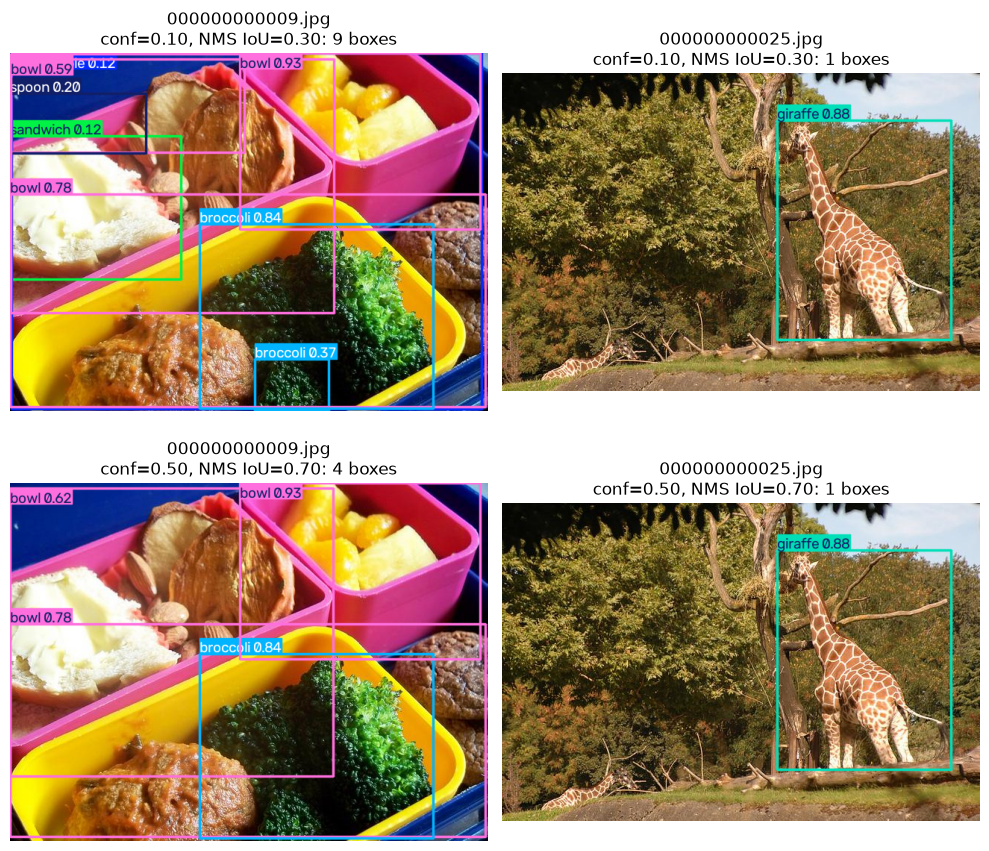

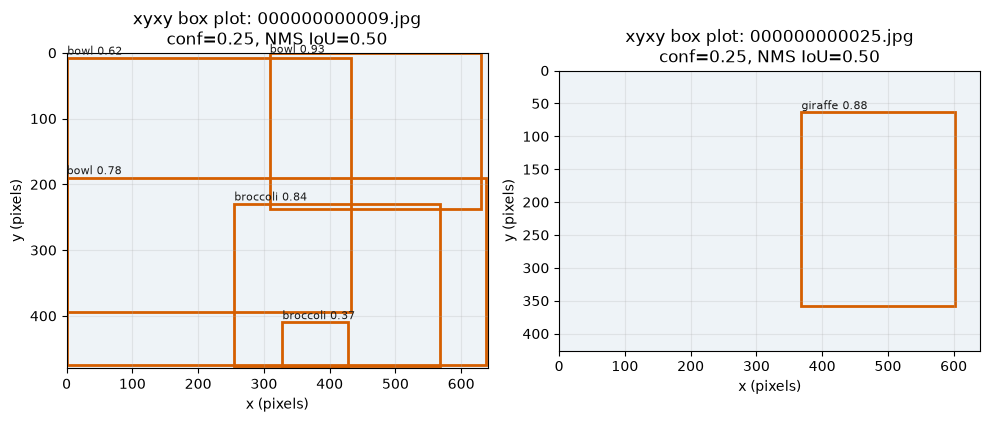

In [11]:
# Real annotated images: compare final boxes under two threshold settings.
fig, axes = plt.subplots(len(VISUAL_SETTINGS), len(image_paths), figsize=(5 * len(image_paths), 4.5 * len(VISUAL_SETTINGS)))
axes = np.atleast_2d(axes)
for row_index, setting in enumerate(VISUAL_SETTINGS):
    confidence_threshold, nms_iou = setting
    for column_index, (image_path, result) in enumerate(zip(image_paths, visual_predictions[setting])):
        axis = axes[row_index, column_index]
        axis.imshow(result.plot()[..., ::-1])  # Ultralytics plot is BGR; Matplotlib expects RGB.
        axis.set_title(f"{image_path.name}\nconf={confidence_threshold:.2f}, NMS IoU={nms_iou:.2f}: {len(result.boxes)} boxes")
        axis.axis("off")
plt.tight_layout()
plt.show()

# Box plot: documented xyxy coordinates for the same real images at the middle setting.
fig, axes = plt.subplots(1, len(image_paths), figsize=(5 * len(image_paths), 4.5))
axes = np.atleast_1d(axes)
for axis, image_path, result in zip(axes, image_paths, box_plot_results):
    height, width = result.orig_shape
    axis.set_xlim(0, width)
    axis.set_ylim(height, 0)
    axis.set_aspect("equal")
    axis.set_facecolor("#eef3f7")
    boxes = result.boxes.xyxy.detach().cpu().numpy()
    scores = result.boxes.conf.detach().cpu().numpy()
    classes = result.boxes.cls.detach().cpu().numpy().astype(int)
    for box, score, class_id in zip(boxes, scores, classes):
        x1, y1, x2, y2 = box
        axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#d55e00", linewidth=2))
        axis.text(x1, max(0, y1 - 5), f"{result.names[class_id]} {score:.2f}", fontsize=8, color="#1b1b1b")
    axis.set_title(f"xyxy box plot: {image_path.name}\nconf={BOX_PLOT_SETTING[0]:.2f}, NMS IoU={BOX_PLOT_SETTING[1]:.2f}")
    axis.set_xlabel("x (pixels)")
    axis.set_ylabel("y (pixels)")
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


> TODO: Compare your predictions with the observed threshold effects (E3).


## 3. Implement class-aware greedy NMS

The five supplied boxes form two overlapping pairs plus one separate different-class box. At IoU threshold `0.50`, the hand trace should keep indices `[0, 2, 4]`.

In [12]:
toy_boxes = np.array([
    [0.0, 0.0, 4.0, 4.0],
    [0.5, 0.5, 4.5, 4.5],
    [5.0, 0.0, 9.0, 4.0],
    [5.4, 0.2, 9.4, 4.2],
    [0.0, 6.0, 3.0, 9.0],
])
toy_scores = np.array([0.95, 0.85, 0.80, 0.70, 0.60])
toy_classes = np.array([0, 0, 0, 0, 1])
print("IoU(pair 0,1)=", round(float(box_iou_one_to_many(toy_boxes[0], toy_boxes[[1]])[0]), 3))
print("IoU(pair 2,3)=", round(float(box_iou_one_to_many(toy_boxes[2], toy_boxes[[3]])[0]), 3))

IoU(pair 0,1)= 0.62
IoU(pair 2,3)= 0.747


In [13]:
# TODO: Complete class-aware greedy NMS and return original indices in keep order.
# HINT: Work one class at a time; score-sort, keep best, suppress IoU > threshold, repeat.

def class_aware_nms(boxes, scores, classes, iou_threshold=0.50):
    boxes = np.asarray(boxes, dtype=float)
    scores = np.asarray(scores, dtype=float)
    classes = np.asarray(classes)
    if len(boxes) != len(scores) or len(scores) != len(classes):
        raise ValueError("boxes, scores, and classes must have equal length.")

    kept = []
    for class_id in np.unique(classes):
        remaining = np.flatnonzero(classes == class_id)
        remaining = remaining[np.argsort(-scores[remaining], kind="stable")]
        while len(remaining):
            best = int(remaining[0])
            kept.append(best)
            if len(remaining) == 1:
                break
            other = remaining[1:]
            overlaps = box_iou_one_to_many(boxes[best], boxes[other])
            remaining = other[overlaps <= iou_threshold]
    return sorted(kept, key=lambda index: -scores[index])

In [14]:
kept = class_aware_nms(toy_boxes, toy_scores, toy_classes, iou_threshold=0.50)
print("base classes kept:", kept)
assert kept == [0, 2, 4]

changed_classes = toy_classes.copy()
changed_classes[1] = 1  # Box 1 overlaps box 0, but now represents another class.
kept_after_class_change = class_aware_nms(toy_boxes, toy_scores, changed_classes, iou_threshold=0.50)
print("after box 1 changes class:", kept_after_class_change)
assert kept_after_class_change == [0, 1, 2, 4]
print("Box 1 is retained because class-aware NMS does not compare it with class-0 box 0.")

base classes kept: [0, 2, 4]
after box 1 changes class: [0, 1, 2, 4]
Box 1 is retained because class-aware NMS does not compare it with class-0 box 0.
